
## Import des bibliothèques nécessaires

In [10]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

## Création du jeu de données 

In [4]:

import numpy as np

jours = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']  
heures = ['12am', '1am', '2am', '3am', '4am', '5am', '6am', '7am', '8am', '9am', 
          '10am', '11am', '12pm', '1pm', '2pm', '3pm', '4pm', '5pm', '6pm', '7pm', 
          '8pm', '9pm', '10pm', '11pm']

data = [] 
for jour in jours: 
    for heure in heures: 
        if jour in ['Friday', 'Saturday', 'Sunday'] and heure in ['7pm', '8pm']:
            valeur = np.random.randint(8000, 12000) 
        elif jour in ['Friday', 'Saturday', 'Sunday']: 
            valeur = np.random.randint(4000, 8000) 
        else: 
            valeur = np.random.randint(1000, 4000) 
        data.append([jour, heure, valeur]) 


## Vérification du format du DataFrame

In [5]:
df = pd.DataFrame(data, columns=['jour', 'heure', 'ventes en Dh']) 
df.head() 

,jour,heure,ventes en Dh
0,Sunday,12am,6787
1,Sunday,1am,4291
2,Sunday,2am,6820
3,Sunday,3am,6887
4,Sunday,4am,7478


## Pivotement des données 

In [6]:
df_pivot = df.pivot(index='heure', columns='jour', values='ventes en Dh') 
df_pivot.head() 

jour,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
heure,,,,,,,
10am,5965,1475,4220,6248,3336,1564,1432
10pm,6199,1465,5271,7806,1555,2682,1650
11am,5994,2731,6559,5618,1203,3900,3097
11pm,4359,3359,5729,5628,1050,2041,1499
12am,6220,1144,5026,6787,3476,1633,2017


## nitialisation du graphique radar

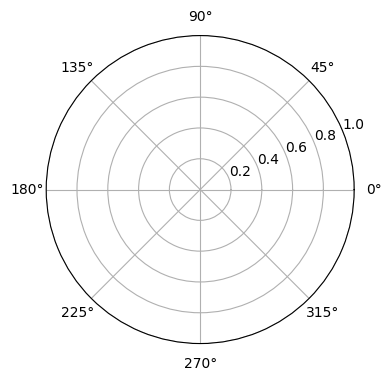

In [16]:
fig, ax = plt.subplots(figsize=(5, 4), subplot_kw=dict(polar=True)) 


## Création du graphique radar pour chaque jour 

In [18]:
for jour in jours: 
    valeurs = df_pivot[jour].values 
    angles = np.linspace(0, 2 * np.pi, len(heures), endpoint=False).tolist() 
    valeurs = np.concatenate((valeurs, [valeurs[0]])) # Ajouter la première val 
    angles += angles[:1] # Ajouter l'angle de départ pour fermer le graphique 
    ax.plot(angles, valeurs, label=jour) # Tracer la courbe pour chaque jour 
    ax.fill(angles, valeurs, alpha=0.25) # Remplir la zone sous la courbe 

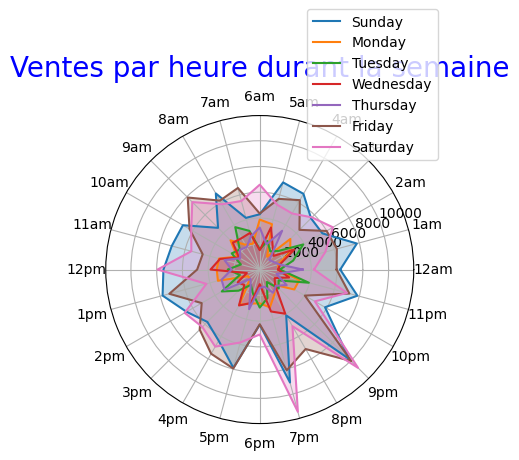

In [25]:
fig, ax = plt.subplots(figsize=(5, 4), subplot_kw=dict(polar=True)) 
for jour in jours: 
    valeurs = df_pivot[jour].values 
    angles = np.linspace(0, 2 * np.pi, len(heures), endpoint=False).tolist() 
    valeurs = np.concatenate((valeurs, [valeurs[0]])) # Ajouter la première val 
    angles += angles[:1] # Ajouter l'angle de départ pour fermer le graphique 
    ax.plot(angles, valeurs, label=jour) # Tracer la courbe pour chaque jour 
    ax.fill(angles, valeurs, alpha=0.25) # Remplir la zone sous la courbe ax.set_yticklabels([]) 
ax.set_xticks(np.linspace(0, 2 * np.pi, len(heures), endpoint=False))##position des heures
ax.set_xticklabels(heures) 
plt.title('Ventes par heure durant la semaine', size=20, color='blue', y=1.1) 
plt.legend(loc='right', bbox_to_anchor=(1.1, 1.1)) 
plt.show() 

